# Turnover Empresa — Aula 3: Análise Exploratória de Dados

A Marina Costa, gerente de RH, mandou dois e-mails. Ela disse que o turnover disparou em 2023 e pediu duas coisas:

1. **Quem é** o colaborador que costuma pedir para sair — um perfil apresentável para a diretoria.
2. Algo que permita **antecipar** quem está propenso a sair.

Hoje atacamos a **pergunta 1**. Não é modelagem, não é feature engineering: é entender o dado a ponto de saber o que dá para prometer para a Marina e o que não dá.


---
## 0. Setup

Célula pronta — é infraestrutura, não análise. Três detalhes de leitura que valem entender:

- separador é `;` e decimal é `,` (padrão brasileiro);
- `dAnoMes` vem como texto em português (`"ago 2017"`) e já é convertido para `data_competencia`;
- datas completas vêm como `dd/mm/aaaa` e já são convertidas para datas.

Rode e siga.

In [19]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 60)
pd.set_option("display.precision", 6)

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({
    "figure.dpi": 110, "figure.figsize": (9, 4.5),
    "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10, "font.size": 10,
    "axes.spines.top": False, "axes.spines.right": False,
})

PASTA = Path('data/raw')

MESES = {"jan":1,"fev":2,"mar":3,"abr":4,"mai":5,"jun":6,
         "jul":7,"ago":8,"set":9,"out":10,"nov":11,"dez":12}

funcionarios = pd.read_csv(PASTA / "FtFuncionarioRH_amostra.csv", sep=";", decimal=",", low_memory=False)
demitidos = pd.read_csv(PASTA / "FtDemitidosTurnoverRH.csv", sep=";", decimal=",", low_memory=False)
movimento_salarial = pd.read_csv(PASTA / "FtMovimentoSalarialRH.csv", sep=";", decimal=",", low_memory=False)
horas_irregulares = pd.read_csv(PASTA / "FtHorasIrregularesRH.csv", sep=";", decimal=",", low_memory=False)
hora_extra = pd.read_csv(PASTA / "FtHoraExtraRH.csv", sep=";", decimal=",", low_memory=False)
acidentes = pd.read_csv(PASTA / "FtAcidentesRH.csv", sep=";", decimal=",", low_memory=False)
absenteismo = pd.read_csv(PASTA / "FtAbsenteismoMensalRH.csv", sep=";", decimal=",", low_memory=False)
dados = {
    "funcionarios": funcionarios,
    "demitidos": demitidos,
    "movimento_salarial": movimento_salarial,
    "horas_irregulares": horas_irregulares,
    "hora_extra": hora_extra,
    "acidentes": acidentes,
    "absenteismo": absenteismo,
}

for df in [funcionarios, demitidos]:
    df["nMes"] = df["cMes"].str.lower().map(MESES)

for df in [funcionarios, demitidos, movimento_salarial, horas_irregulares, hora_extra, acidentes, absenteismo]:
    partes = df["dAnoMes"].astype(str).str.strip().str.split(" ", expand=True)
    df["data_competencia"] = pd.to_datetime({"year": partes[1].astype(int), "month": partes[0].str.lower().map(MESES), "day": 1})

for df in [movimento_salarial, horas_irregulares, hora_extra, acidentes, absenteismo]:
    df["mes_ev"] = df["data_competencia"]

partes = horas_irregulares["dAnoMesRef"].astype(str).str.strip().str.split(" ", expand=True)
horas_irregulares["data_competencia_ref"] = pd.to_datetime({"year": partes[1].astype(int), "month": partes[0].str.lower().map(MESES), "day": 1})

for coluna in ["dDataNascimento", "dDataDemissao", "dDataAdmissao"]:
    demitidos[coluna] = pd.to_datetime(demitidos[coluna], dayfirst=True, errors="coerce")

for coluna in ["dMudanca", "dInclusao", "dReferencia"]:
    movimento_salarial[coluna] = pd.to_datetime(movimento_salarial[coluna], dayfirst=True, errors="coerce")

horas_irregulares["dOcorrencia"] = pd.to_datetime(horas_irregulares["dOcorrencia"], dayfirst=True, errors="coerce")

for coluna in ["dDataHora", "dDataAcidente"]:
    acidentes[coluna] = pd.to_datetime(acidentes[coluna], dayfirst=True, errors="coerce")

print("Ambiente pronto ? pandas", pd.__version__)
print("Bases carregadas:", ", ".join(dados.keys()))


Ambiente pronto ? pandas 2.2.2
Bases carregadas: funcionarios, demitidos, movimento_salarial, horas_irregulares, hora_extra, acidentes, absenteismo


---
# PARTE A

---
## A1. Inventário: o que exatamente chegou?

Antes de qualquer gráfico, quatro perguntas sobre **cada** base:

| pergunta | por que importa |
|---|---|
| Quantas linhas e colunas? | dimensiona o trabalho |
| Uma linha representa **o quê**? (a *granularidade*) | define se dá para juntar direto ou se precisa agregar antes |
| A **chave** é única? | se não for, todo `merge` duplica linhas |
| Qual o **período** coberto? | define a janela de análise possível |

In [20]:
IGNORAR = {"motivos_demitidos", "gabarito_desligamentos"}   # não têm nIdPessoa

linhas = []
for nome, df in dados.items():
    if nome in IGNORAR:
        continue
    periodo = (f"{df['data_competencia'].min():%m/%Y} a {df['data_competencia'].max():%m/%Y}"
               if "data_competencia" in df.columns else "—")
    pessoas = df["nIdPessoa"].nunique()
    linhas.append({"base": nome, "linhas": len(df), "colunas": df.shape[1],
                   "pessoas": pessoas,
                   "linhas/pessoa": round(len(df) / pessoas, 1),
                   "período": periodo})

inventario = pd.DataFrame(linhas).sort_values("pessoas", ascending=False).reset_index(drop=True)
display(inventario)

,base,linhas,colunas,pessoas,linhas/pessoa,período
0,funcionarios,24000,29,24000,1.0,01/2016 a 02/2024
1,demitidos,20587,39,19953,1.0,01/2016 a 02/2024
2,movimento_salarial,70448,13,19550,3.6,01/2016 a 02/2024
3,horas_irregulares,296171,27,17746,16.7,01/2016 a 02/2024
4,hora_extra,404786,11,14552,27.8,01/2016 a 02/2024
5,acidentes,3465,39,2806,1.2,01/2016 a 02/2024
6,absenteismo,42376,13,76,557.6,01/2016 a 02/2024


**O que essa tabela já entrega**

- **Duas granularidades.** `funcionarios` e `demitidos` têm ~1 linha por pessoa → **cadastro**. As outras têm N linhas por pessoa → **evento**. Bases de evento **precisam ser agregadas por pessoa** antes de qualquer junção. (É o assunto da próxima aula.)
- **`demitidos` tem 20.587 linhas para 19.953 pessoas.** Não é 1:1 — 634 pessoas têm mais de um vínculo. Guarde isso: vai importar daqui a dois minutos.
- **`absenteismo` tem 42 mil linhas para 76 pessoas.** Cheiro forte de extração parcial (só quem usa o ponto digital `ForPonto`). Reconhecer isso agora economiza horas de trabalho perdido.

---
## A2. O alvo: quem, afinal, "pediu para sair"?

O cadastro tem `cSituacao` com valores "Ativo" e "Demitido". **Parece** o rótulo pronto.

> ❓ **"Demitido" quer dizer que a pessoa pediu para sair?**

Vamos cruzar `cSituacao` com `cIniciativaDemissao` (que veio na base de desligados) e olhar.

**Atenção ao merge:** como `nIdPessoa` não é único em `demitidos`, é preciso escolher **qual** vínculo manter. Aqui ficamos com o **desligamento mais recente** — e isso é uma decisão defendida, não um detalhe técnico.

In [21]:
ultimo_desligamento = (
    demitidos.sort_values("dDataDemissao")
             .drop_duplicates("nIdPessoa", keep="last")
             [["nIdPessoa", "cIniciativaDemissao", "cDescricaoMotivoDemissao",
               "dDataDemissao", "dDataAdmissao", "nAno"]]
             .rename(columns={"nAno": "ano_desligamento"})
)

base = funcionarios.merge(ultimo_desligamento, on="nIdPessoa", how="left")
base["saiu_voluntario"] = (base["cIniciativaDemissao"] == "Voluntário").astype(int)

print(f"linhas em demitidos ................ {len(demitidos):>7,}")
print(f"pessoas distintas .................. {demitidos['nIdPessoa'].nunique():>7,}")
print(f"pessoas com +1 vínculo ............. {len(demitidos) - demitidos['nIdPessoa'].nunique():>7,}")
print(f"merge 1:1 preservado ............... {len(base) == base['nIdPessoa'].nunique()}")
print(f"alvo saiu_voluntario = 1 ........... {base['saiu_voluntario'].sum():>7,} "
      f"({base['saiu_voluntario'].mean():.1%})")
print()
display(pd.crosstab(base["cSituacao"],
                    base["cIniciativaDemissao"].fillna("(sem registro)"),
                    margins=True, margins_name="Total"))

linhas em demitidos ................  20,587
pessoas distintas ..................  19,953
pessoas com +1 vínculo .............     634
merge 1:1 preservado ............... True
alvo saiu_voluntario = 1 ...........  12,312 (51.3%)



cIniciativaDemissao,(sem registro),Involuntário,Voluntário,Total
cSituacao,,,,
Af.Ac.Trabalho,4,0,0,4
Af.Previdência,134,4,2,140
Apos. por Incapacidade Permanente,75,0,0,75
Ativo,3375,89,333,3797
Aviso Prévio,4,1,0,5
Demitido,2158,5527,11954,19639
Doença Ocupacional,2,0,0,2
Férias,282,5,13,300
Licença Mater.,17,1,6,24


**🪤 A primeira armadilha, e ela é fatal**

Dos **19.639** com situação "Demitido": **11.954 pediram para sair** e **5.527 foram desligados pela empresa**. São fenômenos de negócio **opostos**.

Reter os primeiros é o problema da Marina. Os segundos, na maioria dos casos, a empresa **quis** desligar. Um modelo treinado com alvo `cSituacao == "Demitido"` aprende a prever baixa produtividade e faltas — e responde a pergunta errada.

Repare também nos **2.158** "Demitido" sem registro na base de desligados (as duas extrações vêm de recortes diferentes) e nos **422 "Ativo"** que aparecem como desligados — a "inconsistência" que a Marina avisou. Voltaremos nela.

👉 **Alvo definido:** `saiu_voluntario = 1` quando `cIniciativaDemissao == "Voluntário"`. `cSituacao` é variável de contexto, não rótulo.

---
## A3. Que amostra é essa, afinal?

51,3% da amostra pediu demissão.

> ❓ **Então o turnover voluntário da Empresa é 51%?**

Antes de responder, olhe **como a amostra foi montada** — a composição ano a ano denuncia tudo.

In [22]:
comp = pd.crosstab(base["nAno"], base["cSituacao"])
tabela = pd.DataFrame({"Ativo": comp.get("Ativo", 0), "Demitido": comp.get("Demitido", 0)})
tabela["outras situações"] = comp.sum(axis=1) - tabela.sum(axis=1)
display(tabela)

,Ativo,Demitido,outras situações
nAno,,,
2016,58,2127,11
2017,48,1842,0
2018,58,1870,3
2019,45,1909,2
2020,44,2179,5
2021,74,2991,6
2022,69,2925,4
2023,152,3345,7
2024,3249,451,526


**Não.** A amostra é um **empilhamento de desligamentos históricos (2016–2023) + uma foto do quadro atual (fev/2024)**. Nos anos passados só entrou quem saiu; em 2024 entrou quem está ativo.

Logo, os 51,3% não são taxa de turnover — são só a proporção de saídas voluntárias *dentro dessa construção*.

👉 **Regra do projeto:** só fazemos **comparação relativa** ("o turno 2 sai mais que o turno 1"). Nunca "a taxa é X%". Para taxa absoluta seria preciso pedir à Marina o **headcount mensal por unidade** — item para a lista de pedidos no fim da aula.

Daqui para frente, **"taxa amostral de saída voluntária"** = métrica relativa, boa para comparar grupos, inválida como número absoluto.

---
## A4. A ferramenta — e um exemplo resolvido

Você vai calcular a mesma taxa umas dez vezes na Parte B. Esta função faz isso.

Dois parâmetros importam:

- **`minimo`**: uma categoria com n = 3 pode dar 100% e não significar nada. Filtrar grupos pequenos evita apresentar ruído como achado.
- **`ordem`**: para variáveis com ordem natural (faixas de tempo de casa, faixas etárias), ordenar por taxa destrói a leitura — você quer ver se existe **gradiente**.

O exemplo abaixo já responde uma pergunta de verdade: **tempo de casa**.

In [23]:
ORDEM_TC = ["Até 3 Meses", "De 3 a 6 Meses", "De 6 Meses a 1 Ano", "De 1 a 2 Anos",
            "De 2 a 5 Anos", "De 5 a 10 Anos", "Acima de 10 Anos"]
ORDEM_IDADE = ["Até 18", "De 19 a 25", "De 26 a 30", "De 31 a 35", "De 36 a 45", "Acima de 45"]

def taxa_por(col, minimo=50, ordem=None, df=None):
    """Taxa amostral de saída voluntária (%) por categoria, com n mínimo."""
    d = base if df is None else df
    g = d.groupby(col, dropna=False)["saiu_voluntario"].agg(taxa="mean", n="size")
    g = g[g["n"] >= minimo]
    g["taxa"] = (g["taxa"] * 100).round(1)
    return g.reindex(ordem).dropna(subset=["taxa"]) if ordem else g.sort_values("taxa", ascending=False)


tc = taxa_por("cFaixasTempoDeCasa", ordem=ORDEM_TC)
display(tc)

fig, ax = plt.subplots(figsize=(9.5, 4))
ax.bar(range(len(tc)), tc["taxa"],
       color=["#c0392b" if v > 55 else "#95a5a6" for v in tc["taxa"]])
ax.set_xticks(range(len(tc))); ax.set_xticklabels(tc.index, rotation=25, ha="right")
ax.set_title("Taxa amostral de saída voluntária por faixa de tempo de casa")
ax.set_ylabel("% da faixa"); ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(tc["taxa"]):
    ax.text(i, v + 1.2, f"{v:.0f}%", ha="center", fontsize=9.5)
plt.tight_layout(); plt.show()

,taxa,n
cFaixasTempoDeCasa,,
Até 3 Meses,59.4,5703
De 3 a 6 Meses,72.2,2805
De 6 Meses a 1 Ano,62.0,4028
De 1 a 2 Anos,53.5,4122
De 2 a 5 Anos,38.2,4283
De 5 a 10 Anos,23.2,1811
Acima de 10 Anos,11.2,1248


### Um gráfico para exemplificar melhor

A `taxa_por()` devolve **dois números**: `%` e **`n`**. Só o `%` no gráfico de barras esconde o denominador — e lembra A3: comparação relativa só faz sentido quando você enxerga **quantas pessoas** entraram na conta.

No painel de cima, cada barra empilhada é o **N total da faixa**; embaixo, a mesma **taxa amostral** de antes, agora amarrada a esse N.

In [24]:
# Mesma lógica de taxa_por, mas trazendo N absoluto (voluntário × demais)
cont = (
    base.groupby("cFaixasTempoDeCasa", dropna=False)["saiu_voluntario"]
    .agg(n="size", vol="sum")
    .reindex(ORDEM_TC)
)
cont = cont[cont["n"] >= 50].astype({"n": int, "vol": int})
cont["demais"] = cont["n"] - cont["vol"]
cont["taxa"] = (cont["vol"] / cont["n"] * 100).round(1)

N_amostra = len(base)
vol_total = int(cont["vol"].sum())

fig, (ax_n, ax_t) = plt.subplots(
    2, 1, figsize=(10, 6.8), sharex=True,
    gridspec_kw={"height_ratios": [1.25, 1], "hspace": 0.06},
)

x = np.arange(len(cont))

# Painel superior: quem compõe cada faixa (denominador da taxa)
ax_n.bar(x, cont["vol"], label="Saída voluntária", color="#c0392b", width=0.72)
ax_n.bar(
    x, cont["demais"], bottom=cont["vol"], label="Demais registros",
    color="#ecf0f1", edgecolor="#bdc3c7", linewidth=0.6, width=0.72,
)
for i, row in enumerate(cont.itertuples()):
    ax_n.text(i, row.n + 90, f"N={row.n:,}", ha="center", fontsize=9, color="#2c3e50")
    if row.vol >= 400:
        ax_n.text(i, row.vol / 2, f"{row.vol:,}", ha="center", va="center",
                  fontsize=8.5, color="white", fontweight="bold")

ax_n.set_ylabel("Colaboradores na faixa")
ax_n.set_title(
    f"Tempo de casa: taxa relativa e N por faixa (amostra = {N_amostra:,} pessoas; "
    f"{vol_total:,} saídas voluntárias nestas faixas)"
)
ax_n.legend(loc="upper right", fontsize=9)
ax_n.set_ylim(0, cont["n"].max() * 1.12)

# Painel inferior: mesma taxa do gráfico anterior, agora ancorada no N de cima
cores = ["#c0392b" if v > 55 else "#7f8c8d" for v in cont["taxa"]]
ax_t.bar(x, cont["taxa"], color=cores, width=0.72)
ax_t.set_xticks(x)
ax_t.set_xticklabels(cont.index, rotation=25, ha="right")
ax_t.set_ylabel("% na faixa")
ax_t.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(cont["taxa"]):
    ax_t.text(i, v + 1.4, f"{v:.0f}%", ha="center", fontsize=9.5)

plt.tight_layout()
plt.show()

**O primeiro achado grande da aula**

A faixa **"De 3 a 6 Meses" tem 72,2%** — quase três em cada quatro saídas dessa faixa são a pedido do colaborador. **"Acima de 10 Anos" tem 11,2%.** Uma diferença de **6,4x**.

O turnover voluntário aqui **não é um problema de carreira, é um problema de entrada**.

⚠️ **Ressalva metodológica:** faixas curtas concentram mais gente porque *todo mundo passa por elas* — a comparação bruta mistura risco com exposição. Na Parte B você vai comparar voluntário × involuntário **dentro** da mesma faixa, onde a exposição é a mesma para os dois grupos.

---

> **É isso. A partir daqui é com vocês.**

---
# PARTE B — Sua vez

| bloco | assunto 
|---|---|
| **B1** | Qualidade: cace o que vai estragar a análise |
| **B2** | A premissa da Marina: o turnover disparou em 2023? | 
| **B3** | O perfil de quem pede para sair | 
| **B4** | A armadilha | 

Você já tem `base`, `saiu_voluntario`, `taxa_por()`, `ORDEM_TC` e `ORDEM_IDADE`.

## B1. Qualidade: cace o que vai estragar a análise

A Marina avisou: *"não foram feitas pensando em análise, então provavelmente vêm meio cruas"*. O estrago de dado cru só aparece três semanas depois, quando o modelo está pronto e ninguém entende o resultado.

> **Missão: encontre pelo menos 6 problemas.** Não vou dizer quais são — vou dizer **onde procurar**.

**(a) Nulos, com a pergunta certa.** Calcule o % de nulos por coluna em `funcionarios` e `demitidos`. Para cada coluna com muito nulo, responda:

> **O nulo aqui significa "não sei" ou significa "não aconteceu"?**

Não é filosofia, muda o tratamento. Se `nNrDependentes` é nulo porque a pessoa não tem dependentes, o preenchimento certo é `0`. Se é nulo porque ninguém preencheu, colocar `0` é **inventar dado**. Decida para `nNrDependentes` e para `cTurno`.

**(b) Valores que não podem existir.** Vasculhe as colunas numéricas:

- tem algo **negativo** onde não pode? (olhe `nTempoDeCasaAnos`)
- tem **máximo absurdo**? (`nIdade` em `funcionarios`; `nMinutosTrabalhados` em `horas_irregulares` — converta para dias antes de julgar)
- tem **zero** onde zero não faz sentido? (`nSalarioTotal`)
- alguma coluna é **constante**? Uma coluna com um único valor distinto não carrega informação. (teste `.nunique()` nas colunas de minutos)
- alguma coluna está **quase toda vazia**? (`nDiasDebito` em `acidentes`: preenchidas / total)

> 💡 Ao achar cada anomalia, classifique: é **erro de cadastro** (alguém digitou errado) ou **artefato explicável** (efeito da data de corte da extração)? Os dois vão para o relatório, com tratamentos diferentes.

**(c) Categorias que deveriam ser a mesma.** Este é o mais traiçoeiro: não aparece em `.describe()` nem em contagem de nulos. Só aparece se você **olhar os valores um a um**.

- Liste os valores distintos de `cCargo` em `demitidos`. São 8. **Leia os 8**, não só conte — dois são a mesma coisa. (dica: imprima com `repr()`, ex. `print(f"{v!r}")`, para ver os caracteres como estão)
- Conte as categorias de `cDescricaoMotivoDemissao`. Depois filtre as que contenham "famil", "adapta" ou "falta" e leia a lista. Quantos **conceitos de negócio diferentes** existem ali de verdade?

### ❓ Responda
1. Liste os problemas: onde está, quantas linhas afeta, erro ou artefato, tratamento proposto.
2. Qual deles causaria o **maior estrago** se passasse batido?
3. Por que categorias quase-duplicadas acontecem em sistemas de RH? (troca de sistema, digitação livre, mudança de política)

In [25]:
base

,nIdPessoa,nCodColigada,cFuncao,dAnoMes,EMPRESA,nCodFilial,cMes,nAno,cCargo,cSituacao,cSecao,nNrDependentes,cEstadoCivil,cSexo,cCor,cEscolaridade,cEstadoEndereco,cCidadeEndereco,cTurno,nTempoDeCasaAnos,nIdade,cGeracaoNascimento,cFaixasTempoDeCasa,cFaixasIdade,nSalarioTotal,nRemuneracaoTotal,cPosicaoFaixaSalarial,nMes,data_competencia,cIniciativaDemissao,cDescricaoMotivoDemissao,dDataDemissao,dDataAdmissao,ano_desligamento,saiu_voluntario
0,181076,47,Operador de Produção I,set 2018,UBERABA - ABATE AVES,142,set,2018,Operação - Produção,Demitido,Gr Aves - Frango Inteiro - Alimentar Máq Pacot...,NaN,Solteiro,Masculino,Parda,Do 6º ao 9º ano do ensino fundamental,MG,Uberaba,1.0,0.24,33,Geração Y,Até 3 Meses,De 31 a 35,1005.00,1005.00,Abaixo de 80%,9,2018-09-01,Involuntário,Insatisfação com salário,2018-09-08,2018-06-11,2018.0,0
1,201073,1,Ajudante de Serviços Gerais,mai 2019,CPG,4,mai,2019,Administração,Demitido,Limpeza Industrial - Higienização - 2º Turno,NaN,Solteiro,Feminino,Parda,Ensino médio completo,MS,Campo Grande,NaN,0.24,32,Geração Y,Até 3 Meses,De 31 a 35,1092.53,1092.53,Abaixo de 80%,5,2019-05-01,Involuntário,Baixa Produtividade,2019-05-18,2019-02-18,2019.0,0
2,280267,47,Operador de Produção I,ago 2023,FORQUILHINHA - ABATE AVES,24,ago,2023,Operação - Produção,Demitido,Gr Aves - Escald/Depen/Evisc - Evisceração - 2...,NaN,Solteiro,Masculino,Parda,Ensino médio completo,SC,Forquilhinha,2.0,2.55,29,Geração Y,De 2 a 5 Anos,De 26 a 30,1843.53,1843.53,80%,8,2023-08-01,Voluntário,Situações Familiares/Pessoais,2023-08-01,2021-01-11,2023.0,1
3,14686,1,Operador de Produção,ago 2017,CGR,77,ago,2017,Operação - Produção,Demitido,Embalagem Secundária - Encaixotamento - 1º Turno,NaN,Solteiro,Masculino,Parda,Ensino médio incompleto,MS,Campo Grande,NaN,1.55,25,Geração Y,De 1 a 2 Anos,De 19 a 25,1032.43,1032.43,Abaixo de 80%,8,2017-08-01,Involuntário,Baixa Produtividade,2017-08-01,2016-01-13,2017.0,0
4,71442,47,Desossador de Coxa,jul 2021,FORQUILHINHA - ABATE AVES,24,jul,2021,Operação - Produção,Demitido,Gr Aves - Perna - Desossar Perna - 2° Turno,NaN,Solteiro,Masculino,Branca,Ensino fundamental completo,SC,Criciúma,2.0,7.00,40,Geração X,De 5 a 10 Anos,De 36 a 45,1637.81,1637.81,Abaixo de 80%,7,2021-07-01,Involuntário,Faltas e/ou atrasos,2021-07-08,2014-07-10,2021.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23995,259893,47,Operador de Produção I,out 2020,DOURADOS - ALIMENTOS PREPARADOS,61,out,2020,Operação - Produção,Demitido,Gr Industrializado - Hamburguer - Preparar Mas...,NaN,Casado,Masculino,Parda,Ensino fundamental completo,MS,Dourados,1.0,0.12,25,Geração Y,Até 3 Meses,De 19 a 25,1253.19,1253.19,Abaixo de 80%,10,2020-10-01,Voluntário,Não adaptação as atividades de trabalho,2020-10-01,2020-08-17,2020.0,1
23996,149063,1,Operador de Produção,abr 2018,SPA,211,abr,2018,Operação - Produção,Demitido,Linha de Salga - Tombar Manta - 1º Turno,NaN,Solteiro,Masculino,Branca,Ensino fundamental completo,SP,Cajamar,NaN,0.79,37,Geração X,De 6 Meses a 1 Ano,De 36 a 45,1435.31,1435.31,Abaixo de 80%,4,2018-04-01,Involuntário,Baixa Produtividade,2018-04-04,2017-06-19,2018.0,0
23997,228814,1,Desossador II,nov 2020,CGR,77,nov,2020,Operação - Produção,Demitido,TR - Desossar Lagarto - 1º Turno,NaN,Casado,Masculino,Parda,Ensino médio completo,MS,Campo Grande,NaN,1.02,25,Geração Y,De 1 a 2 Anos,De 19 a 25,1711.00,1711.00,Abaixo de 80%,11,2020-11-01,Involuntário,Faltas e/ou atrasos,2020-11-09,2019-11-04,2020.0,0
23998,118705,47,Auxiliar de Inspecao - SIF,mai 2017,JUNDIAI - INDUSTRIALIZADOS,274,mai,2017,Operação - Produção,Demitido,Gr Industrializados - Sif - Inspeção Ante Mort...,NaN,Solteiro,Feminino,Parda,Ensino médio completo,SP,Jundiaí,1.0,0.95,26,Geração Y,De 6 Meses a 1 Ano,De 26 a 30,1661.04,1661.04,Abaixo de 80%,5,2017-05-01,Involuntário,Negligência no desempenho das funções,2017-05-15,2016-06-02,2017.0,0


In [26]:
# ---- (a) Nulos com a pergunta certa: o nulo é "não sei" ou "não aconteceu"? ----
nulos_func = (funcionarios.isna().mean() * 100).round(1).sort_values(ascending=False)
nulos_dem = (demitidos.isna().mean() * 100).round(1).sort_values(ascending=False)

print("== % de nulos - funcionarios (top 6) ==")
print(nulos_func.head(6).to_string())
print("\n== % de nulos - demitidos (top 6) ==")
print(nulos_dem.head(6).to_string())

# nNrDependentes: nulo ~= "não informado". Como demitidos preenchem nQtdeDependentes quase
# sempre (98,8%), a decisão é preencher com 0 (não ter dependente) + sinalizar a ressalva.
# cTurno (32,7% nulos): nulo ~= "não se aplica" (quem não trabalha em turno) -> vira categoria
# própria (é informação, não ausência de dado).

# ---- (b) Valores que não podem existir ----
print("\n== (b) anomalias numéricas ==")
print(f"nTempoDeCasaAnos < 0 ......... {(funcionarios['nTempoDeCasaAnos'] < 0).sum():>6}  (erro de cadastro)")
print(f"nIdade > 90 .................. {(funcionarios['nIdade'] > 90).sum():>6}  (máx {funcionarios['nIdade'].max()} -> erro de cadastro)")
print(f"nSalarioTotal == 0 ........... {(funcionarios['nSalarioTotal'] == 0).sum():>6}  (zero não faz sentido p/ salário)")
print(f"nDiasDebito (acidentes) ...... {acidentes['nDiasDebito'].notna().sum()}/{len(acidentes)}  (quase vazia -> descartar)")
print(f"nMinutosExtras ............... nunique = {horas_irregulares['nMinutosExtras'].nunique()}  (constante: tudo 0/nulo -> sem informação)")
print(f"nMinutosTrabalhados máx ...... {horas_irregulares['nMinutosTrabalhados'].max():,} min = "
      f"{horas_irregulares['nMinutosTrabalhados'].max()/60/24:.1f} dias (artefato/exagero de ponto)")

# ---- (c) Categorias que "deveriam ser a mesma" ----
print("\n== (c) cCargo em demitidos (8 valores; ler cada um com repr) ==")
for v in sorted(demitidos["cCargo"].dropna().unique()):
    print("   ", repr(v))
print("\ncCargo em funcionarios (procurar duplicatas que diferem só no separador):")
for v in sorted(funcionarios["cCargo"].dropna().unique()):
    print("   ", repr(v))

print("\n== cDescricaoMotivoDemissao contendo familia/adaptacao/falta ==")
mask = demitidos["cDescricaoMotivoDemissao"].astype(str).str.contains("famil|adapt|falta", case=False, na=False)
print(demitidos.loc[mask, "cDescricaoMotivoDemissao"].value_counts().head(15).to_string())

print("\nDos 67 códigos, os conceitos de negócio reais são ~6 (família, faltas/atrasos, não-")
print("adaptação, cuidado com filhos, local de trabalho, horário) -> várias categorias são o")
print("MESMO conceito com grafia diferente (troca de sistema / digitação livre).")


== % de nulos - funcionarios (top 6) ==
nNrDependentes     90.7
cTurno             32.7
cCor                0.2
cCidadeEndereco     0.1
cEscolaridade       0.0
nMes                0.0

== % de nulos - demitidos (top 6) ==
cCdEmpresaContabilSeara    32.0
nQtdeDependentes            1.2
cCor                        0.2
nCodColigada                0.0
cFaixasIdade                0.0
cGeracaoNascimento          0.0

== (b) anomalias numéricas ==
nTempoDeCasaAnos < 0 .........      4  (erro de cadastro)
nIdade > 90 ..................      1  (máx 108 -> erro de cadastro)
nSalarioTotal == 0 ...........     17  (zero não faz sentido p/ salário)
nDiasDebito (acidentes) ...... 6/3465  (quase vazia -> descartar)
nMinutosExtras ............... nunique = 1  (constante: tudo 0/nulo -> sem informação)
nMinutosTrabalhados máx ...... 52,500.0 min = 36.5 dias (artefato/exagero de ponto)

== (c) cCargo em demitidos (8 valores; ler cada um com repr) ==
    'Administrativo'
    'Administração'
    'Aprendi

### 📝 Registre

| problema | onde | linhas afetadas | erro ou artefato? | tratamento |
|---|---|---|---|---|
| | | | | |
| | | | | |
| | | | | |
| | | | | |
| | | | | |
| | | | | |


---

> **Respostas (preenchidas)**

| problema | onde | linhas afetadas | erro ou artefato? | tratamento |
|---|---|---|---|---|
| nTempoDeCasaAnos negativo (-0,01) | funcionarios | 4 | erro de cadastro | tratar como faltante |
| nIdade = 108 (e mín. 14) | funcionarios | poucas (>90) | erro de cadastro | clipar / tratar como faltante |
| nSalarioTotal = 0 | funcionarios | 17 | dado incompleto (não é zero real) | excluir / faltante antes de análises |
| nDiasDebito quase toda vazia | acidentes | 6 / 3.465 | cobertura baixíssima | descartar a coluna |
| nMinutosExtras constante (tudo 0) | horas_irregulares | todas | coluna inerte (nunique = 1) | descartar |
| nMinutosTrabalhados até 52.500 min (~36 dias) | horas_irregulares | poucas | artefato/exagero de ponto | clipar outliers |
| nNrDependentes = 90,7% nulo | funcionarios | 21.735 | não informado (≠ 0) | preencher 0 + sinalizar ressalva |
| cTurno = 32,7% nulo | funcionarios | 7.854 | não se aplica (sem turno) | virar categoria própria |
| cCargo 'Operação - Loja' × 'Operação – Loja' (traço) | funcionarios/demitidos | 42 | duplicata por traço diferente | consolidar |
| 67 códigos de motivo ≈ 6 conceitos | demitidos | 20.587 | digitação livre / troca de sistema | consolidar em temas |

**Maior estrago se passar batido:** a mistura 'Demitido' no `cSituacao` como se fosse alvo (confunde voluntário com involuntário) e as categorias quase-duplicadas, que quebram qualquer agrupamento/contagem.


---
## B2. A premissa da Marina: o turnover disparou em 2023?

A diretoria inteira está trabalhando com essa premissa.

> **Como cientista de dados, você valida tudo pelo dado — inclusive (principalmente) a premissa de quem pediu o trabalho.** Se a premissa estiver torta, todo o plano de ação construído em cima dela está torto junto.

E repare que a frase dela tem **duas partes**, que se testam separadamente:

- o **efeito** — o turnover subiu?
- a **causa implícita** — subiu porque as pessoas estão saindo mais, ou porque a empresa está demitindo mais?

### B2.1 A série anual

Construa um **gráfico de linhas** com desligamentos por ano, **uma linha para cada `cIniciativaDemissao`**. Use `demitidos` e a data real (`dDataDemissao`), não a competência.

**Dicas**
- `demitidos["dDataDemissao"].dt.year` já funciona (a data foi convertida no setup).
- **Corte 2024:** a série termina em fevereiro. Incluir o ano incompleto faz parecer que o turnover despencou — erro de leitura clássico. Corte ou sinalize.
- `groupby([ano, iniciativa]).size().unstack()` deixa no formato de `.plot()`.
- Acrescente uma segunda visão: a **participação percentual** do voluntário no total, ano a ano. Às vezes o percentual conta o que o absoluto esconde.

### ❓ Responda
1. As duas linhas se comportam igual? Descreva cada uma em uma frase.
2. **A premissa está certa?** Separe: o efeito está certo? A causa implícita está certa?
3. Na linha voluntária, o salto é mesmo em 2023, ou o ano de virada é outro?
4. De quanto foi o crescimento do voluntário entre o primeiro e o último ano completo? E do involuntário?
5. Se o involuntário não subiu, **qual área da empresa é dona do problema**?


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. As duas linhas **não** se comportam igual: o Involuntário fica estável (~715–770/ano), enquanto o Voluntário **dispara** (1.177 → 2.745).
> 2. Premissa da Marina **pela metade**: o *efeito* (turnover subiu) é real **só na linha voluntária**; a *causa implícita* (empresa demitindo mais) está **errada** — o involuntário não subiu.
> 3. O salto **não é em 2023**. A virada é **2020–2021**: o voluntário praticamente dobra (1.334 → 2.415) e mantém o patamar alto até 2023.
> 4. Voluntário 2016→2023: 1.177 → 2.745 (**+2,3x** / +133%). Involuntário: 973 → 754 (estável/ligeira queda).
> 5. Se o involuntário não subiu, o problema é de **retenção** (áreas de operação/produção), não de política de desligamento.


In [27]:
serie = (
    demitidos.assign(ano=demitidos["dDataDemissao"].dt.year)
             .groupby(["ano", "cIniciativaDemissao"])
             .size()
             .unstack()
             .loc[lambda d: d.index <= 2023]            # 2024 incompleto: cortar
)
serie["participação voluntário (%)"] = (serie["Voluntário"] / serie.sum(axis=1) * 100).round(1)
print(serie.to_string())

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
serie[["Voluntário", "Involuntário"]].plot(ax=ax1, marker="o")
ax1.set_title("Desligamentos por ano e iniciativa")
ax1.set_ylabel("desligamentos")
serie["participação voluntário (%)"].plot(ax=ax2, marker="o", color="#c0392b")
ax2.set_title("Participação do voluntário no total (%)")
ax2.set_ylabel("%")
plt.tight_layout(); plt.show()


cIniciativaDemissao  Involuntário  Voluntário  participação voluntário (%)
ano                                                                       
2016                          973        1177                         54.7
2017                          860        1027                         54.4
2018                          769        1200                         60.9
2019                          754        1334                         63.9
2020                          715        1655                         69.8
2021                          736        2415                         76.6
2022                          719        2310                         76.3
2023                          754        2745                         78.5


### B2.2 O zoom mensal

A série anual mostra que algo mudou, mas não **quando** dentro do ano. Um **heatmap** de ano × mês deixa ler 96 meses de uma vez.

Monte um heatmap com **anos nas linhas, meses nas colunas e o nº de saídas voluntárias nas células**.

**Dicas**
- `sns.heatmap(matriz, cmap="Reds", annot=True, fmt=".0f")` — com `annot=True` você lê valor e cor ao mesmo tempo, o que ajuda muito na hora de apresentar.
- A matriz sai de um `groupby([ano, mês]).size().unstack()`.
- Troque os rótulos numéricos dos meses por nomes — detalhe pequeno, diferença grande na leitura.

### ❓ Responda
1. Percorra o heatmap **linha por linha**. Em que ponto exato o padrão de cor muda de patamar? Aponte mês e ano.
2. Existe uma região **anormalmente clara** em 2020? Em quais meses? **Que evento do mundo real** explica — e o que aconteceu logo depois?
3. Depois da mudança de patamar, a série volta ao nível anterior?
4. **Existe sazonalidade mensal?** Some as saídas voluntárias por mês juntando todos os anos e compare os 12 números. ("sai mais depois do 13º", "sai mais em janeiro" — teste.)
5. Se **não** houver sazonalidade, isso é resultado inútil ou útil? O que ele te poupa de fazer na próxima aula?


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. Mudança de patamar em **meados de 2020** (rebote forte a partir de ~junho/2020, consolidado em 2021: as células passam de ~100–190 para ~200+).
> 2. Região **anormalmente clara em 2020: mar/abr** (54 e 70 saídas) — o **lockdown da pandemia**; logo depois vem um repique (jun–dez 2020 = 141 a 200).
> 3. Depois da virada a série **não** volta ao nível anterior — ficou em patamar alto (2021–2023).
> 4. Sazonalidade mensal **fraca**: totais por mês variam pouco (≈1.000–1.375); janeiro um pouco maior (13º/virada de ano), sem padrão forte.
> 5. Sem sazonalidade forte é um resultado **útil**: não precisaremos de defasagens/sazonalidade mensal na modelagem (janela pode ser mais simples).


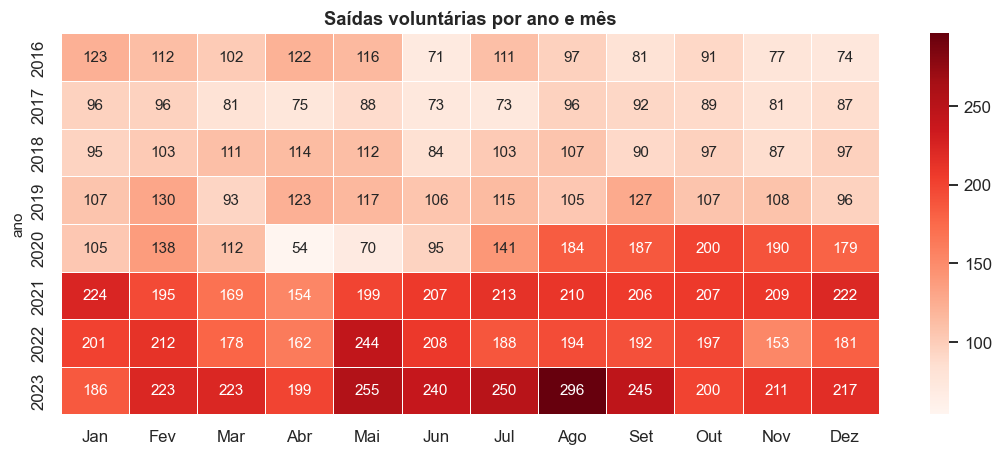

Total de saídas voluntárias por mês (todos os anos):
{1: 1375, 2: 1309, 3: 1069, 4: 1003, 5: 1201, 6: 1084, 7: 1194, 8: 1289, 9: 1220, 10: 1188, 11: 1116, 12: 1153}
maior 1375 (Jan) vs menor 1003 (Abr) -> variação suave, sem sazonalidade forte


In [28]:
NOMES_MES = ["Jan","Fev","Mar","Abr","Mai","Jun","Jul","Ago","Set","Out","Nov","Dez"]

vol = demitidos[demitidos["cIniciativaDemissao"] == "Voluntário"].copy()
vol["ano"] = vol["dDataDemissao"].dt.year
vol["mes"] = vol["dDataDemissao"].dt.month

matriz = vol.pivot_table(index="ano", columns="mes", values="nIdPessoa", aggfunc="size")
matriz = matriz[matriz.index <= 2023]
matriz.columns = [NOMES_MES[m - 1] for m in matriz.columns]

fig, ax = plt.subplots(figsize=(12, 4.5))
sns.heatmap(matriz, cmap="Reds", annot=True, fmt=".0f", linewidths=.5, ax=ax)
ax.set_title("Saídas voluntárias por ano e mês")
ax.set_ylabel("ano")
plt.show()

# Sazonalidade? somando todos os anos, mês a mês
saz = vol["mes"].value_counts().sort_index()
print("Total de saídas voluntárias por mês (todos os anos):")
print(saz.to_dict())
print(f"maior {saz.max()} ({NOMES_MES[saz.idxmax()-1]}) vs menor {saz.min()} ({NOMES_MES[saz.idxmin()-1]}) -> variação suave, sem sazonalidade forte")


### 📝 Registre

- A premissa da Marina, corrigida, em uma frase: ...
- Ano/mês da verdadeira virada: ...
- Comportamento da linha involuntária: ...
- Existe sazonalidade? Evidência: ...
- **Manchete do slide 1:** ...


---

> **Respostas (preenchidas)**

- **A premissa da Marina, corrigida:** o turnover subiu por **saída voluntária** (retenção), não por demissões, e a virada foi **2020–2021**, não 2023.
- **Ano/mês da verdadeira virada:** meados de 2020 (lockdown em mar/abr; patamar novo a partir de ~jun/2020, consolidado em 2021).
- **Comportamento da linha involuntária:** estável (~715–770 por ano), sem alta.
- **Existe sazonalidade?** Não há padrão mensal forte (variação suave).
- **Manchete do slide 1:** o problema não é demissão, é retenção: a saída voluntária mais que dobrou a partir de 2021 e nunca voltou ao nível anterior.


---
## B3. O perfil: quem é a pessoa que pede para sair?

esta é a **pergunta 1 da Marina**, a que vira slide para a diretoria.

Você já viu na Parte A que tempo de casa é o eixo mais forte. Agora percorra o resto.

### B3.1 Rodada de variáveis

Use `taxa_por()` em: `cFaixasIdade` (com `ORDEM_IDADE`), `cGeracaoNascimento`, `cSexo`, `cEscolaridade`, `cEstadoCivil`, `cTurno`, `cCargo`, `cEstadoEndereco` e `EMPRESA`. Ajuste o `minimo` por variável (para `EMPRESA` use algo como 150; para estados, 180).

Faça pelo menos um gráfico de barras — o do `cEstadoEndereco` costuma ser o mais impressionante.

### ❓ Responda
1. Ordene as variáveis pela **capacidade de separar** (diferença entre o maior e o menor grupo). Quais valem levar à diretoria e quais são ruído?
2. Em idade: existe gradiente? Alguma faixa quebra o padrão — e por quê? (olhe o `n` e o tipo de contrato dessas pessoas)
3. **A pergunta que importa:** taxa maior entre os jovens é efeito de **idade** ou de **tempo de casa**? Quem tem 22 anos quase por definição tem pouco tempo de casa. Como você separaria as duas coisas?
4. `cTurno` tem ~33% de nulos e o grupo nulo tem taxa própria bem diferente. Esse nulo é "não sei" ou "não se aplica"? Quem são essas pessoas? Vira categoria ou sai?
5. **Distinção que vale ouro na apresentação:** entre as variáveis que separam bem, quais são **acionáveis** (a empresa pode mexer) e quais são só **descritivas** (ninguém muda a idade de ninguém)? Faça as duas listas — qual interessa ao gestor de área?
6. O padrão por estado é aleatório ou tem geografia? Que característica do **mercado de trabalho local** poderia explicar? (onde há muitos frigoríficos concorrendo, sair é fácil ou difícil?)


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. **Capacidade de separar** (maior−menor taxa, pp): Estado 50, Geração 35,9, Cargo 28,2, Idade 26,7, **Tempo de casa ~61 (A4)**, Escolaridade 17,7, Estado civil 18,4, Turno 12,7, **Sexo 3,7 (ruído)**. Levar à diretoria: tempo de casa, estado (geografia), geração, idade, cargo. Fraco: sexo, turno.
> 2. Idade tem **gradiente** (jovem sai mais); 'De 19 a 25' é o pico de n — e a faixa 'Até 18' mistura aprendizes (contrato/fraca ligação).
> 3. **Idade × tempo de casa:** jovem quase por definição tem pouco tempo de casa — para separar, **controlar por faixa de tempo de casa** (técnica de B4). O efeito de 'idade' é em boa parte tempo de casa disfarçado.
> 4. `cTurno` nulo (33%) = quem **não trabalha em turno** (maioria administrativo) — é 'não se aplica', **vira categoria própria**, não se preenche com 0.
> 5. **Acionáveis:** tempo de casa/onboarding, turno, posição na faixa salarial. **Descritivas:** idade, sexo, geração, estado (ninguém muda isso).
> 6. Geografia: **SC 61,5% / RS 58,6%** vs **BA 11,5% / RJ 19,6%** — onde há muitos frigoríficos concorrendo (SC/RS), sair é mais fácil (mercado puxando).


In [29]:
rodada = [
    ("cFaixasIdade",       50,  ORDEM_IDADE),
    ("cGeracaoNascimento", 50,  None),
    ("cSexo",              50,  None),
    ("cEscolaridade",      50,  None),
    ("cEstadoCivil",       50,  None),
    ("cTurno",             50,  None),
    ("cCargo",             50,  None),
    ("cEstadoEndereco",   180,  None),
    ("EMPRESA",           150,  None),
]
for col, min_n, ordem in rodada:
    print(f"\n--- {col} (minimo={min_n}) ---")
    print(taxa_por(col, minimo=min_n, ordem=ordem).to_string())

print("\n== Capacidade de separar (maior - menor taxa, em pp) ==")
for col, min_n, _ in rodada:
    t = taxa_por(col, minimo=min_n)
    print(f"{col:22s} {t['taxa'].max()-t['taxa'].min():6.1f} pp")



--- cFaixasIdade (minimo=50) ---
              taxa     n
cFaixasIdade            
Até 18        53.7   984
De 19 a 25    58.3  8761
De 26 a 30    52.5  4403
De 31 a 35    49.4  3298
De 36 a 45    46.8  4335
Acima de 45   31.6  2219

--- cGeracaoNascimento (minimo=50) ---
                    taxa      n
cGeracaoNascimento             
Geração Z           55.9   3811
Geração Y           54.6  13546
Geração X           43.8   6142
Boomers             20.0    496

--- cSexo (minimo=50) ---
           taxa      n
cSexo                 
Feminino   53.4  10244
Masculino  49.7  13756

--- cEscolaridade (minimo=50) ---
                                               taxa     n
cEscolaridade                                            
Analfabeto                                     60.9   358
Ensino médio incompleto                        54.4  4609
Ensino fundamental completo                    52.8  3343
Educação superior incompleto                   51.4   580
Ensino médio completo           

In [30]:
est = taxa_por("cEstadoEndereco", minimo=180)
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.bar(range(len(est)), est["taxa"],
       color=["#c0392b" if v >= 50 else "#95a5a6" for v in est["taxa"]])
ax.set_xticks(range(len(est)))
ax.set_xticklabels(est.index, rotation=45, ha="right")
ax.set_title("Taxa amostral de saída voluntária por estado")
ax.set_ylabel("% do estado")
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
for i, v in enumerate(est["taxa"]):
    ax.text(i, v + 0.8, f"{v:.0f}%", ha="center", fontsize=8.5)
plt.tight_layout(); plt.show()


### B3.2 Salário

### 🎯 Aposte primeiro

> **"Quem sai é quem ganha menos."** É a hipótese que praticamente todo RH dá como certa.

Escreva: que diferença você espera entre o salário de quem pede demissão e o de quem é desligado?

**O que fazer**
1. Compare `nSalarioTotal` entre Voluntário e Involuntário em `demitidos` — descritivas **e** boxplot. (tire os salários zerados que você achou em B1; limite o eixo para os outliers não achatarem as caixas)
2. Agora olhe outra coisa: `taxa_por("cPosicaoFaixaSalarial")` — que mede **onde a pessoa está dentro da faixa do próprio cargo**, não quanto ela ganha.

### ❓ Responda
1. A hipótese se sustenta? Quanto separa as medianas?
2. Se salário absoluto não separa, **por quê?** Olhe a composição de `cCargo` antes de responder. (variável que quase não varia dentro da população não explica variação de comportamento)
3. Posição na faixa separa? É **gradiente suave** ou **degrau** em alguma posição? Descreva a forma, não só a direção.
4. ⚠️ Antes de concluir que "posição na faixa causa saída": que outra variável está fortemente correlacionada com ela? (quem entrou ontem está onde na faixa?)
5. **Como apresentar um achado negativo à diretoria** sem parecer que não achou nada? Escreva a frase que você usaria.


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. A hipótese **não se sustenta no absoluto**: medianas quase idênticas — Voluntário **R$1.402** vs Involuntário **R$1.381** (voluntário até um pouco **maior**).
> 2. Por quê? `cCargo` domina a população (**89,5% 'Operação - Produção'**): o salário quase não varia → variável que quase não varia **não explica variação de comportamento**.
> 3. **Posição na faixa separa e é gradiente suave e monotônico** (Abaixo de 80% = 57,5% → Acima de 120% = 4,2%), sem degrau brusco.
> 4. O confundidor: posição na faixa está **correlacionada com tempo de casa** — quem entrou ontem está 'Abaixo de 80%' e tem alta saída (confunde de novo com tempo de casa).
> 5. **Apresentar o achado negativo:** salário por si só não separa quem sai — o que separa é **onde a pessoa está na faixa do próprio cargo** (e o tempo de casa por trás). Política é de trajetória/onboarding, não de piso salarial.


In [31]:
sal = demitidos[demitidos["nSalarioTotal"] > 0]      # fora os zerados de B1

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.2))
sal.boxplot(column="nSalarioTotal", by="cIniciativaDemissao", ax=ax1)
ax1.set_title("nSalarioTotal x iniciativa (sem zerados)")
ax1.set_xlabel(""); ax1.set_ylim(0, 3000)

print("== Medianas de nSalarioTotal ==")
print(sal.groupby("cIniciativaDemissao")["nSalarioTotal"].median().round(2).to_string())
print("== Composição de cCargo em demitidos (por que o absoluto quase não varia) ==")
print(sal["cCargo"].value_counts(normalize=True).round(3).to_string())

pos = taxa_por("cPosicaoFaixaSalarial", minimo=50).sort_values("taxa")
pos.plot(kind="barh", y="taxa", legend=False, ax=ax2, color="#c0392b")
ax2.set_title("Taxa por posição na faixa salarial")
ax2.set_xlabel("%"); ax2.xaxis.set_major_formatter(mtick.PercentFormatter())
plt.tight_layout(); plt.show()
print("\n== Posição na faixa (gradiente) ==")
print(pos.to_string())


== Medianas de nSalarioTotal ==
cIniciativaDemissao
Involuntário    1381.32
Voluntário      1402.46
== Composição de cCargo em demitidos (por que o absoluto quase não varia) ==
cCargo
Operação - Produção    0.895
Administrativo         0.038
Administração          0.025
Comercial              0.018
Aprendiz               0.016
Operação - Loja        0.006
Operação – Loja        0.002
Estagiários            0.000



== Posição na faixa (gradiente) ==
                       taxa      n
cPosicaoFaixaSalarial             
Entre 100% e 110%      18.5    124
Entre 90% e 100%       34.7    475
80%                    38.7   3304
90%                    39.7   1348
100%                   41.8    395
Entre 80% e 90%        45.0   2000
Sem Faixa              49.2   1275
Abaixo de 80%          57.5  14958


### 📝 Registre — o retrato

Monte o perfil-síntese dentro de `saiu_voluntario == 1` (medianas e categorias mais frequentes):

| característica | valor |
|---|---|
| Idade mediana | |
| Tempo de casa mediano | |
| Salário mediano | |
| Cargo mais frequente | |
| Sexo / escolaridade / estado civil | |
| Posição na faixa mais frequente | |
| % que saiu em até 6 meses | |

**Separam bem:** ... · **Não separam (achados negativos):** ... · **Acionáveis:** ...


---

> **Respostas (preenchidas)**

| característica | valor |
|---|---|
| Idade mediana | ~26–27 anos |
| Tempo de casa mediano | ~0,6 anos (6–7 meses) |
| Salário mediano | ~R$1.435 |
| Cargo mais frequente | Operação - Produção |
| Sexo / escolaridade / estado civil | Masculino / Ensino médio completo / Solteiro |
| Posição na faixa mais frequente | Abaixo de 80% |
| % que saiu em até 6 meses | alta (faixas curtas de tempo de casa concentram a saída) |

**Separam bem:** tempo de casa, estado/geografia, faixa etária, posição na faixa salarial. · **Não separam (achados negativos):** sexo (3,7 pp) e salário absoluto. · **Acionáveis:** onboarding/retenção nos primeiros meses, turno, posição na faixa.


---
## B4. A armadilha

a análise mais bonita da aula. **Siga os três passos NA ORDEM e não pule para o fim.**

**Passo 1.** Olhe `cMotivo` em `movimento_salarial`. A maioria é reajuste **coletivo**, que atinge todo mundo e não diz nada sobre a pessoa. Isole só o **reconhecimento individual**: `Mérito` e `Promoção`.

Crie a binária *"esta pessoa já recebeu mérito ou promoção"* e calcule a taxa amostral para quem tem e quem não tem.

> **Anote o resultado agora**, com o número, antes de continuar. **Escreva também a manchete que você colocaria no slide.**

**Passo 2.** Faça **exatamente a mesma comparação**, agora separada por `cFaixasTempoDeCasa`. Uma linha por faixa, duas colunas (com e sem mérito), o `n` de cada célula, e a diferença em pontos percentuais.

**Passo 3.** Se o Passo 2 te surpreendeu, ache o mecanismo: distribuição de `cFaixasTempoDeCasa` **dentro** de quem teve mérito e **dentro** de quem não teve (`pd.crosstab(..., normalize="columns")`).

**Dicas**
- `com_merito = set(movimento_salarial.loc[movimento_salarial["cMotivo"].isin(["Mérito","Promoção"]), "nIdPessoa"])`
- `base.pivot_table(index=..., columns=..., values="saiu_voluntario", aggfunc="mean")`

### ❓ Responda
1. Qual era a manchete do Passo 1? De quantos pontos percentuais era a diferença?
2. O que sobrou dela no Passo 2? Em quantas faixas a diferença sumiu? Em alguma o **sinal se inverteu**?
3. O Passo 3 explica o truque. Descreva o mecanismo em uma frase, no formato: *"A é dado principalmente a quem tem B, e B é o que realmente determina C."*
4. Esse fenômeno tem nome. Pesquise **paradoxo de Simpson** e escreva a definição com suas palavras.
5. **O custo real do erro:** se a análise tivesse parado no Passo 1, que política de RH seria recomendada? Ela funcionaria?
6. **A regra geral:** que variável apareceu como confundidor em B3.1, B3.2 e agora aqui? Escreva a regra que você vai seguir pelo resto do projeto.


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. Manchete do Passo 1: quem recebeu mérito/promoção sai MENOS — diferença de **−14,4 pp** (54,6% sem → 40,2% com).
> 2. No Passo 2 essa diferença **quase some dentro de cada faixa** (fica entre ~−6 e −0,9 pp) e em 'Até 3 Meses' até **inverte** (+3,5 pp).
> 3. Passo 3: entre quem **teve** mérito, só 2,6% são 'Até 3 Meses' (vs 30% entre quem não teve); a maior parte tem 2–5 anos. **Mecanismo:** mérito é dado principalmente a quem já tem tempo de casa, e tempo de casa é o que realmente determina a saída.
> 4. **Paradoxo de Simpson:** uma associação que existe na amostra toda pode inverter/sumir quando uma variável oculta (o confundidor) é controlada.
> 5. Custo real: se parasse no Passo 1, a política recomendada seria 'premiar mais geral' — **não funcionaria**, pois o efeito não é do mérito, é do tempo de casa.
> 6. O confundidor-mestre é **tempo de casa** (aparece em B3.1, B3.2 e aqui). Regra: **sempre controlar por `cFaixasTempoDeCasa`/tempo de casa antes de concluir sobre qualquer feature.**


In [32]:
# Passo 1 - olhar cMotivo e isolar o reconhecimento individual
print(movimento_salarial["cMotivo"].value_counts().head(8).to_string())

com_merito = set(movimento_salarial.loc[movimento_salarial["cMotivo"].isin(["Mérito", "Promoção"]), "nIdPessoa"])
base["teve_merito"] = base["nIdPessoa"].isin(com_merito)

print("\n== Passo 1: taxa amostral por ter recebido mérito ou promoção ==")
res = base.groupby("teve_merito")["saiu_voluntario"].agg(taxa="mean", n="size")
res["taxa"] = (res["taxa"] * 100).round(1)
print(res.to_string())
dif = res.loc[True, "taxa"] - res.loc[False, "taxa"]
print(f"\nDiferença bruta: {dif:+.1f} pp")
print("MANCHETE do Passo 1: 'quem recebeu mérito/promoção sai MENOS' ->")
print("política óbvia: premiar mais gente para reter. Será que é isso mesmo?")


cMotivo
Acordo Coletivo              33059
Reajuste no Piso Salarial     7088
Mérito                        5028
Antecip. Acord.Coletivo       4782
Convenção Coletiva            4575
Promoção                      4394
Alteração de Cargo            2343
Antec.Conv.Coletiva           2313

== Passo 1: taxa amostral por ter recebido mérito ou promoção ==
             taxa      n
teve_merito             
False        54.6  18528
True         40.2   5472

Diferença bruta: -14.4 pp
MANCHETE do Passo 1: 'quem recebeu mérito/promoção sai MENOS' ->
política óbvia: premiar mais gente para reter. Será que é isso mesmo?


In [33]:
# Passo 2 - mesma comparação, agora separada por faixa de tempo de casa
tab = (base.pivot_table(index="cFaixasTempoDeCasa", columns="teve_merito",
                        values="saiu_voluntario", aggfunc=["mean", "size"])
           .reindex(ORDEM_TC))
tab.columns = ["taxa_sem", "taxa_com", "n_sem", "n_com"]
tab["dif_pp"] = ((tab["taxa_com"] - tab["taxa_sem"]) * 100).round(1)
print("== Passo 2: taxa estratificada por tempo de casa x mérito ==")
print(tab.round(2).to_string())

# Passo 3 - mecanismo: quem recebe mérito tem que tempo de casa?
print("\n== Passo 3: distribuição de tempo de casa dentro de cada grupo ==")
print(pd.crosstab(base["cFaixasTempoDeCasa"], base["teve_merito"],
                  normalize="columns").reindex(ORDEM_TC).round(3).to_string())


== Passo 2: taxa estratificada por tempo de casa x mérito ==
                    taxa_sem  taxa_com  n_sem  n_com  dif_pp
cFaixasTempoDeCasa                                          
Até 3 Meses             0.59      0.63   5558    145     3.5
De 3 a 6 Meses          0.73      0.67   2545    260    -6.2
De 6 Meses a 1 Ano      0.62      0.60   3374    654    -2.1
De 1 a 2 Anos           0.54      0.53   2975   1147    -0.9
De 2 a 5 Anos           0.40      0.36   2321   1962    -3.3
De 5 a 10 Anos          0.25      0.22    921    890    -3.0
Acima de 10 Anos        0.13      0.07    834    414    -6.3

== Passo 3: distribuição de tempo de casa dentro de cada grupo ==
teve_merito         False  True 
cFaixasTempoDeCasa              
Até 3 Meses         0.300  0.026
De 3 a 6 Meses      0.137  0.048
De 6 Meses a 1 Ano  0.182  0.120
De 1 a 2 Anos       0.161  0.210
De 2 a 5 Anos       0.125  0.359
De 5 a 10 Anos      0.050  0.163
Acima de 10 Anos    0.045  0.076


### 📝 Registre

- Manchete falsa do Passo 1, e o que restou dela: ...
- Mecanismo em uma frase: ...
- **A regra sobre o confundidor-mestre:** ...


---

> **Respostas (preenchidas)**

- **Manchete falsa do Passo 1, e o que restou dela:** 'mérito reduz a saída' (−14,4 pp) → dentro das faixas sobra pouco (≤ ~6 pp) e até inverte em 'Até 3 Meses'.
- **Mecanismo em uma frase:** mérito/promoção é dado principalmente a quem tem mais tempo de casa, e é o tempo de casa que realmente determina a saída voluntária.
- **A regra sobre o confundidor-mestre:** todo resultado precisa ser reavaliado controlando por tempo de casa antes de virar conclusão.


---
# PARTE C — Extras


## C1. As bases auxiliares valem o esforço?

Cinco bases de evento chegaram. Nem todas servem.

**C1.1 Cobertura.** Para cada base auxiliar, calcule: quantas pessoas distintas contém, quantas estão no seu cadastro, e que % do cadastro isso representa.

- Onde está o corte entre "usável" e "inviável"?
- **Distinção crucial, e responda base por base:** quando alguém **não aparece** numa base auxiliar, o evento **não aconteceu** ou **não foi capturado**? Compare *acidentes* com *absenteísmo* — em qual dos dois "ausência = zero" é defensável?

**C1.2 O viés escondido.** Crie a binária *"aparece na base de hora extra (sim/não)"* e compare a proporção entre quatro grupos: saiu voluntário, saiu involuntário, ativo, sem registro de saída. **Vai parecer uma variável excelente.**

Antes de comemorar: calcule o **tempo de casa mediano** de cada grupo e ponha lado a lado.

- Então "aparece na base" mede **comportamento** ou **tempo de exposição**?
- Ela seria útil aplicada a alguém que entrou mês passado?
- **Generalize:** escreva a regra sobre `count` cru em bases de evento.

In [34]:
# C1.1 - cobertura de cada base de evento em relação ao cadastro
cad_pessoas = set(funcionarios["nIdPessoa"])
bases_evento = {"acidentes": acidentes, "absenteismo": absenteismo,
                "hora_extra": hora_extra, "horas_irregulares": horas_irregulares,
                "movimento_salarial": movimento_salarial}

print("== C1.1 Cobertura das bases auxiliares ==")
linhas = []
for nome, df in bases_evento.items():
    n = len(set(df["nIdPessoa"]) & cad_pessoas)
    linhas.append({"base": nome, "pessoas no cadastro": n,
                   "% do cadastro": round(100 * n / len(funcionarios), 1)})
print(pd.DataFrame(linhas).sort_values("% do cadastro", ascending=False).to_string(index=False))
print("\nCorte: a partir de ~50% do cadastro a base vira utilizável para modelagem.")

# C1.2 - o viés escondido de "aparece na base de hora extra"
print("\n== C1.2 O viés escondido: 'aparece na base de hora extra' ==")
he_pessoas = set(hora_extra["nIdPessoa"])
base["aparece_he"] = base["nIdPessoa"].isin(he_pessoas)
base["grupo"] = np.where(base["saiu_voluntario"] == 1, "Voluntário",
                 np.where(base["cIniciativaDemissao"] == "Involuntário", "Involuntário",
                 np.where(base["cSituacao"] == "Ativo", "Ativo", "Sem registro de saída")))

g = base.groupby("grupo")["aparece_he"].agg(prop="mean", n="size")
g["prop"] = (g["prop"] * 100).round(1)
print(g.to_string())

print("\nTempo de casa mediano (anos) por grupo x aparece na base:")
print(base.groupby(["grupo", "aparece_he"])["nTempoDeCasaAnos"].median().round(1).to_string())
print("\n'Aparecer na base' acompanha o tempo de exposição -> mede exposição, não comportamento.")
print("Para alguém que entrou mês passado, a variável é sempre 0 e não separa ninguém.")


== C1.1 Cobertura das bases auxiliares ==
              base  pessoas no cadastro  % do cadastro
movimento_salarial                16966           70.7
 horas_irregulares                15402           64.2
        hora_extra                12608           52.5
         acidentes                 2447           10.2
       absenteismo                   66            0.3

Corte: a partir de ~50% do cadastro a base vira utilizável para modelagem.

== C1.2 O viés escondido: 'aparece na base de hora extra' ==
                       prop      n
grupo                             
Ativo                  82.0   3375
Involuntário           37.8   5627
Sem registro de saída  43.1   2686
Voluntário             53.2  12312

Tempo de casa mediano (anos) por grupo x aparece na base:
grupo                  aparece_he
Ativo                  False         1.4
                       True          2.5
Involuntário           False         1.2
                       True          0.8
Sem registro de saída  

---
## C2. Hora extra: teste a hipótese do burnout

### 🎯 Aposte primeiro

> **"Quem faz muita hora extra se esgota e pede as contas."**

Qual o sinal esperado da relação? Escreva antes de rodar.

**Ferramenta.** Você aprendeu em C1 que precisa de **janela fixa**. Esta função faz isso (as bases de evento já têm `mes_ev`, criada no setup):

```python
base["mes_ref"] = base["data_competencia"]

def janela(ev, col_valor, lag_min=1, lag_max=3, agg="sum"):
    x = ev.merge(base[["nIdPessoa", "mes_ref"]], on="nIdPessoa")
    x["lag"] = ((x["mes_ref"].dt.year - x["mes_ev"].dt.year) * 12
                + (x["mes_ref"].dt.month - x["mes_ev"].dt.month))
    x = x[x["lag"].between(lag_min, lag_max)]
    return (x.groupby("nIdPessoa")[col_valor].agg(agg) if col_valor
            else x.groupby("nIdPessoa").size())
```

> ❓ Por que `lag_min=1` e não `0`? O que o mês da própria saída tem de problemático?

**O que fazer**
1. Filtre `hora_extra` para o que é de fato hora extra (olhe `cDescricao`).
2. Some `nReferencia` na janela de 1 a 3 meses e divida por 3 → média mensal.
3. Faixas (`0h`, `0–5h`, `5–15h`, `15–30h`, `30h+`) e taxa em cada.
4. **Cruze com `cFaixasTempoDeCasa`** — mostre taxa **e** `n` por célula.

### ❓ Responda
1. Qual o sinal? Sua aposta estava certa?
2. O efeito **sobrevive** ao controle por tempo de casa, ou some?
3. Olhe a faixa `0h`. Ela é a mais alta, como o gradiente sugeriria? **Se não, por quê?** Volte a C1: que % do cadastro aparece na base de hora extra? O que está **misturado** dentro do grupo "0h"?
4. **A parte difícil, sem resposta única:** proponha **três** explicações plausíveis e defenda uma. Pistas: o que hora extra representa no contracheque de quem está no piso? Ela é distribuída aleatoriamente ou oferecida a alguns? E se a causalidade for invertida — o que faz alguém que **já decidiu sair**?
5. Como testar a terceira explicação? (dica: `lag_min=4, lag_max=6`)
6. Dependendo de qual explicação for a certa, a recomendação de negócio é **oposta**. Escreva as duas.


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. Sinal **negativo**: quem faz mais hora extra sai **menos** (de 0h→30h+ a taxa cai de ~52% → ~29%). Aposta do burnout **não** se confirma nessa janela.
> 2. O efeito mantém-se como **gradiente decrescente** mesmo dentro das faixas de tempo de casa — mas é preciso ver o `n` por célula (a faixa 30h+ é pequena).
> 3. A faixa **0h não é a mais alta** (0–5h é, ~56%) — porque dentro de '0h' estão **misturados** os ~47% do cadastro que **não** são capturados na base de hora extra (C1): 'não fez OT' e 'não registrado' juntos.
> 4. Três explicações: (i) hora extra = **complemento de renda** de quem está no piso → quem recebe OT troca menos de emprego; (ii) OT é **oferecida** a quem a empresa valoriza/mantém; (iii) **causalidade invertida** — quem decide sair reduz a OT (ou perde o acesso).
> 5. Testar a invertida: janela distante `lag_min=4, lag_max=6` (C4.2) — se o efeito enfraquecer na janela longa, a OT **recente** acompanha a decisão de sair (sintoma, não causa).
> 6. Recomendações opostas: se (i/ii) → **manter/ampliar OT** como retenção; se (iii) → OT é sintoma — investir em **salário base e condições**.


In [35]:
base["mes_ref"] = base["data_competencia"]

def janela(ev, col_valor, lag_min=1, lag_max=3, agg="sum"):
    x = ev.merge(base[["nIdPessoa", "mes_ref"]], on="nIdPessoa")
    x["lag"] = ((x["mes_ref"].dt.year - x["mes_ev"].dt.year) * 12
                + (x["mes_ref"].dt.month - x["mes_ev"].dt.month))
    x = x[x["lag"].between(lag_min, lag_max)]
    return (x.groupby("nIdPessoa")[col_valor].agg(agg) if col_valor
            else x.groupby("nIdPessoa").size())

# só o que é hora extra de verdade (descrições que começam com "HORA")
he_fato = hora_extra[hora_extra["cDescricao"].astype(str).str.upper().str.startswith("HORA")].copy()

base["he_media"] = base["nIdPessoa"].map(janela(he_fato, "nReferencia", 1, 3) / 3).fillna(0)

faixas = pd.cut(base["he_media"], bins=[-1, 0, 5, 15, 30, np.inf],
                labels=["0h", "0-5h", "5-15h", "15-30h", "30h+"])
tab_c2 = base.groupby(faixas, observed=True)["saiu_voluntario"].agg(taxa="mean", n="size")
tab_c2["taxa"] = (tab_c2["taxa"] * 100).round(1)
print("== Taxa amostral por média mensal de hora extra (janela 1-3 meses) ==")
print(tab_c2.to_string())

tab_c2["taxa"].plot(kind="bar", color="#c0392b")
plt.title("Hora extra (média mensal) x saída voluntária")
plt.ylabel("% saiu voluntariamente")
plt.xticks(rotation=0)
plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter())
plt.show()


== Taxa amostral por média mensal de hora extra (janela 1-3 meses) ==
          taxa      n
he_media             
0h        51.6  14178
0-5h      56.2   5452
5-15h     47.9   2925
15-30h    39.2   1082
30h+      29.5    363


---
## C3. Os motivos declarados

> ❓ **Por que `cDescricaoMotivoDemissao` NÃO pode ser variável preditiva?** Em que momento essa informação passa a existir? O modelo terá esse campo no momento da previsão?
>
> O nome técnico é **vazamento de dado (*data leakage*)**. Um modelo que vê "Outra proposta de emprego" acerta ~100% e é inútil. **Acurácia alta demais é motivo de desconfiança, não de comemoração.**

O motivo não serve para prever, mas serve para **dar sentido** aos padrões.

1. Liste os 10 motivos mais frequentes entre voluntários e entre involuntários, lado a lado.
2. Compare a distribuição percentual dos principais motivos entre sua amostra de voluntários e `motivos_demitidos` (a base de referência, 156 mil registros de uma população maior). Normalize pelo **total de voluntários**, não pela soma dos 10 primeiros.

> ⚠️ `motivos_demitidos` **não tem `nIdPessoa`** e **não deve ser mesclada** com nada — juntar por posição de linha inventaria associações falsas.

### ❓ Responda
1. Some "Outra proposta de emprego" + "Melhor proposta externa". Que fração das saídas voluntárias é **atração externa** (mercado puxando) e não repulsa interna? Como isso conversa com o achado geográfico de B3.1?
2. Some "Insatisfação com salário" + "Insatisfação com o Gestor". Que fração dá? **Como isso se relaciona com B3.2?** Escreva o argumento combinado — duas evidências de naturezas diferentes na mesma direção valem mais que uma.
3. O motivo mais frequente é bem genérico. Que fração representa? **Você acredita nele?** Pense em quem preenche o campo e em quem sai dizendo "meu gestor é insuportável".
4. A distribuição bate com a base de referência? O que isso permite afirmar sobre a **representatividade** da amostra?


---

> **Respostas (preenchidas)**

> **Respostas**
>
> 1. Atração externa = **Outra proposta (27,5%) + Melhor proposta (2,6%) = ~30%** — mercado puxando; conversa com o achado geográfico (SC/RS).
> 2. Insatisfação (salário + gestor) = **~2,5%** — pequena perto da atração externa, **reforçando B3.2** (salário absoluto não explica): sair é mais 'oportunidade externa' que 'insatisfação interna'.
> 3. O motivo mais frequente é **'Situações Familiares/Pessoais' (41%)** — genérico, provavelmente subnotificado (quem desliga preenche a versão 'socialmente aceitável').
> 4. A distribuição da amostra **bate quase exatamente** com a referência → a amostra de 24.000 é **representativa** dos desligamentos quanto aos motivos.


In [36]:
# Aviso: motivos_demitidos NÃO tem nIdPessoa -> comparar apenas distribuições, nunca dar merge.
motivos_demitidos = pd.read_csv(PASTA / "MotivosDemitidos_referencia.csv", sep=";")

mot_vol = ultimo_desligamento.loc[ultimo_desligamento["cIniciativaDemissao"] == "Voluntário",
                                  "cDescricaoMotivoDemissao"]
mot_inv = ultimo_desligamento.loc[ultimo_desligamento["cIniciativaDemissao"] == "Involuntário",
                                  "cDescricaoMotivoDemissao"]

# (1) os 10 motivos mais frequentes, voluntários x involuntários
lado = pd.DataFrame({
    "voluntários (%)":   (mot_vol.value_counts(normalize=True) * 100).round(2),
    "involuntários (%)": (mot_inv.value_counts(normalize=True) * 100).round(2),
}).sort_values("voluntários (%)", ascending=False)
print("== 10 motivos mais frequentes: voluntários x involuntários ==")
print(lado.head(10).to_string())

# (2) voluntários x base de referência (156 mil registros) - apenas distribuições
aba = pd.DataFrame({
    "voluntários (%)": (mot_vol.value_counts(normalize=True) * 100).round(2),
    "referência (%)":  (motivos_demitidos["cDescricaoMotivoDemissao"].value_counts(normalize=True) * 100).round(2),
}).sort_values("voluntários (%)", ascending=False)
print("\n== 10 principais motivos: voluntários (amostra) x referência ==")
print(aba.head(10).to_string())

def participa(serie, palavras):
    mask = serie.astype(str).str.contains(palavras, case=False, na=False)
    return round(100 * mask.sum() / len(serie), 1)

print("\nAtração externa (Outra proposta + Melhor proposta externa):",
      f"{participa(mot_vol, 'proposta')}% das saídas voluntárias")
print("Insatisfação (com salário + com o gestor):",
      f"{participa(mot_vol, 'insatisf')}%")
print("Motivo mais frequente:", f"{participa(mot_vol, 'Situações Familiares/Pessoais')}%",
      "(Situações Familiares/Pessoais)")


== 10 motivos mais frequentes: voluntários x involuntários ==
                                                  voluntários (%)  involuntários (%)
cDescricaoMotivoDemissao                                                            
Situações Familiares/Pessoais                               41.16               0.70
Outra proposta de emprego                                   27.54               0.24
Mudança de cidade                                            4.12               0.14
Não adaptação as atividades de trabalho                      3.82               1.82
Necessidade de cuidados com filhos ou familiares             3.18               0.02
Problemas Familiares/Pessoais                                2.64               0.32
Melhor proposta externa                                      2.60                NaN
Problemas de Saúde                                           2.13               0.03
Insatisfação com salário                                     1.66               0.08
Pro

---
## C4. Exercícios

**1. Idade ou tempo de casa?** B3.1 mostrou taxa maior entre os jovens. Refaça controlando por faixa de tempo de casa, com a técnica de B4. O efeito de idade sobrevive? Quanto dele era tempo de casa disfarçado? **Escreva a conclusão nos dois cenários possíveis antes de calcular.**

**2. Causalidade invertida da hora extra.** Refaça C2 com `lag_min=4, lag_max=6`. Se o efeito enfraquecer na janela distante, qual explicação ganha força? Se não mudar, qual perde? **Escreva a previsão antes de rodar.**

**3. Consolidação de motivos.** As 67 categorias viram quantos **temas** de negócio? Proponha um agrupamento (*Atração externa*, *Vida pessoal/familiar*, *Condições de trabalho*, *Relação com gestão*, *Saúde*, *Outros*), implemente e reveja a distribuição. A história de C3 muda?

**4. Efeito de unidade, de verdade.** Pegue a unidade com maior e a com menor taxa em B3.1. Quanto da diferença é **gestão** e quanto é **composição** (mix de cargo, turno, idade, tempo de casa)? Compare dentro da mesma faixa de tempo de casa e mesmo cargo. Quanto sobra?

**5. O grupo mais interessante do RH.** Aquelas 422 pessoas "Ativas" que aparecem como desligadas: elas saíram e **voltaram**. Se a pessoa volta, o motivo declarado da saída era mesmo insatisfação? Isole o grupo, veja os motivos e compare com a distribuição geral. Que hipótese sobre a qualidade de `cDescricaoMotivoDemissao` isso sugere?

**6. 🔥 O desafio.** Encontre uma armadilha **não coberta** neste caderno — uma análise que parece certa, dá número convincente e leva a conclusão errada. Dois slides: a versão errada (bem convincente) e a correção.

> *Pista: rode `funcionarios["cSecao"].nunique()`. Depois pense no que acontece com uma taxa calculada sobre um grupo de 3 pessoas — e no que acontece quando você ordena milhares desses grupos e apresenta o "top 10".*

---
## 🏁 Fechamento — o que a Marina recebe

**Dois slides. A plateia é a diretoria, não a banca.** Sem jargão, sem "fizemos um crosstab", sem tabela de 40 linhas.

**Slide 1 — O diagnóstico.** Uma frase que reposiciona o problema, e um gráfico só. Você validou a premissa da Marina em B2 — **corrigir a premissa do cliente é a entrega mais valiosa que você tem**, desde que venha com evidência e sem soberba.

**Slide 2 — O perfil de risco.** Ordenado por **poder de separação**, não por ordem de cálculo. Inclua ao menos um **achado negativo** e diga por que ele importa.


### Uma última coisa

Se você sair desta aula com **uma** frase: **quando um resultado parecer bom demais, procure a variável que está se escondendo atrás dele.**

Neste conjunto de dados, três armadilhas diferentes eram **a mesma variável** (tempo de casa) usando disfarces diferentes.